In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target


target
1    357
0    212
Name: count, dtype: int64


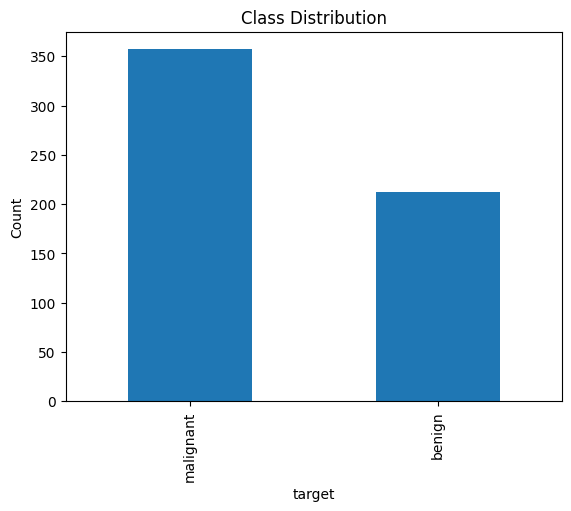

In [3]:
import matplotlib.pyplot as plt
counts = df["target"].value_counts()
print(counts)
df["target"].value_counts().plot(kind="bar")
plt.xticks([0,1], data.target_names)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


In [22]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


10    0.03299
11    0.09954
12    0.20650
13    0.09938
14    0.21280
15    0.16390
16    0.07395
17    0.17220
18    0.14790
19    0.06664
Name: mean concavity, dtype: float64


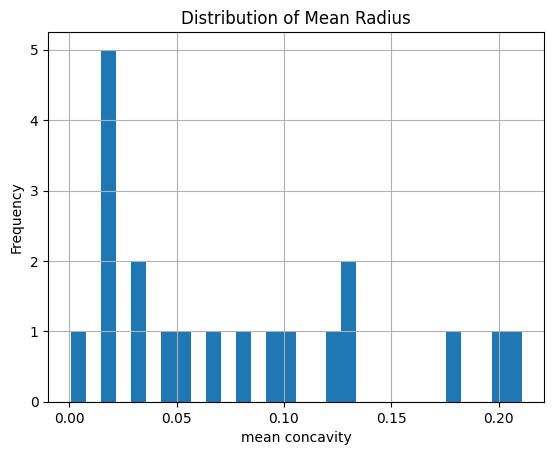

In [25]:


to_show = "mean concavity"
mean_rad = df[to_show][10:20] 
print(df[to_show][10:20])
df[to_show][40:60].hist(bins=30)
plt.title("Distribution of Mean Radius")
plt.xlabel(to_show)
plt.ylabel("Frequency")
plt.show()



10    0.08206
11    0.09710
12    0.09740
13    0.08401
14    0.11310
15    0.11390
16    0.09867
17    0.11700
18    0.09831
19    0.09779
Name: mean smoothness, dtype: float64


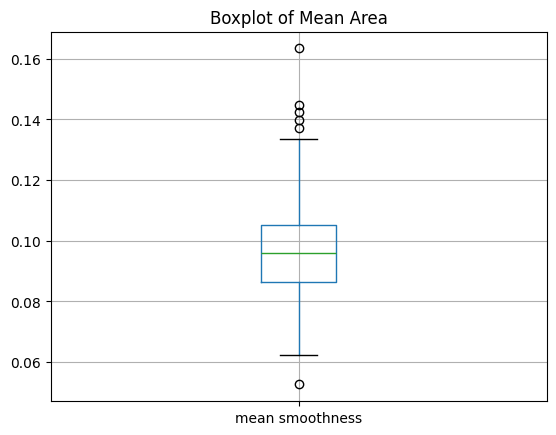

In [30]:
to_show = "mean smoothness"
df_to_plot = df[to_show][10:20] 
print(df[to_show][10:20])

df.boxplot(column=to_show)
plt.title("Boxplot of Mean Area")
plt.show()


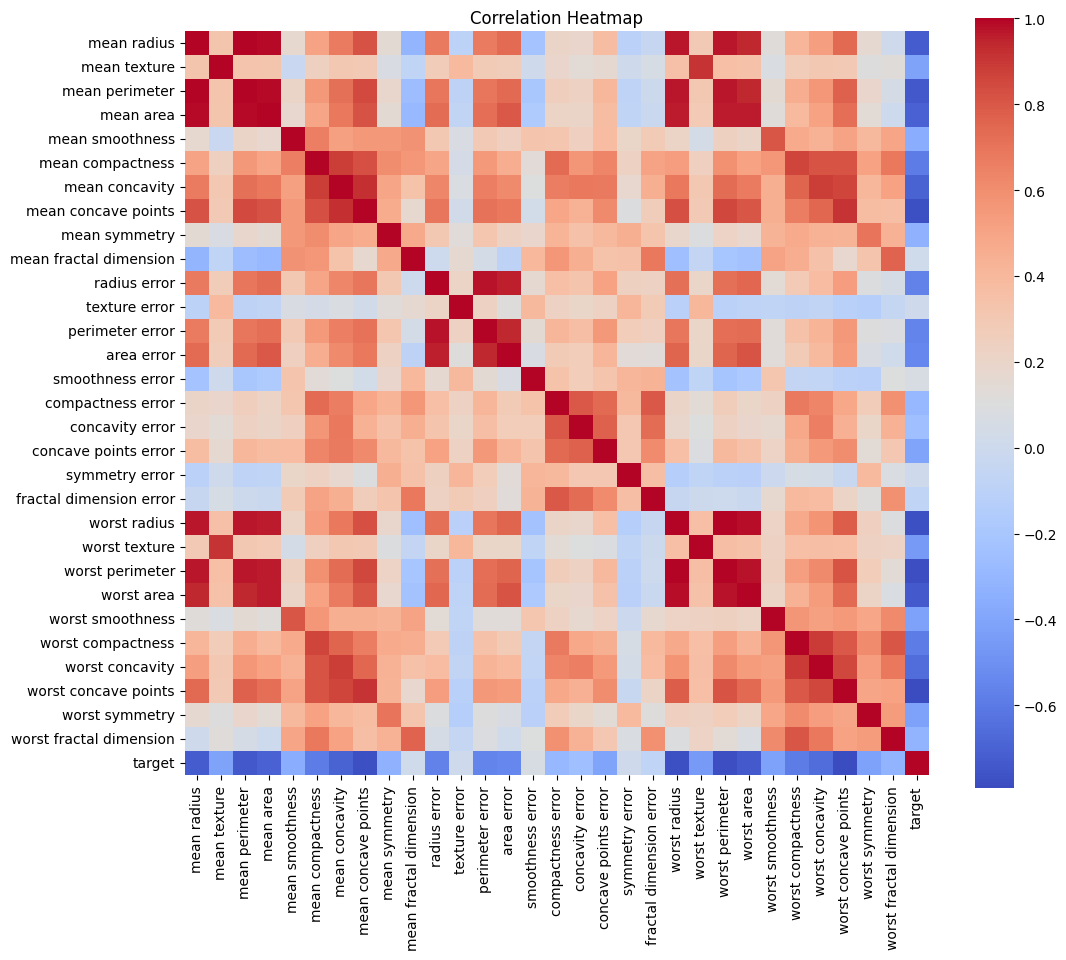

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

# ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
#  'mean smoothness' 'mean compactness' 'mean concavity'
#  'mean concave points' 'mean symmetry' 'mean fractal dimension'
#  'radius error' 'texture error' 'perimeter error' 'area error'
#  'smoothness error' 'compactness error' 'concavity error'
#  'concave points error' 'symmetry error' 'fractal dimension error'
#  'worst radius' 'worst texture' 'worst perimeter' 'worst area'
#  'worst smoothness' 'worst compactness' 'worst concavity'
#  'worst concave points' 'worst symmetry' 'worst fractal dimension']


(569,)
(569,)


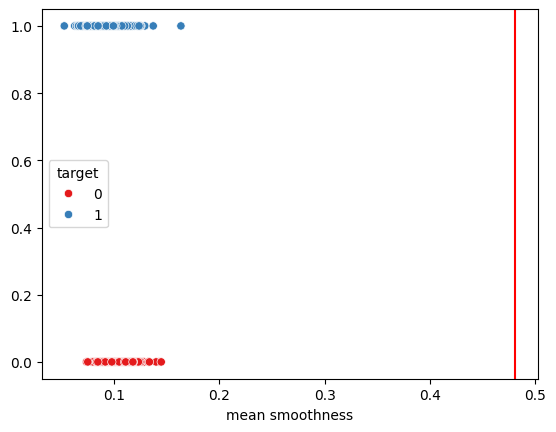

In [54]:
# ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
#  'mean smoothness' 'mean compactness' 'mean concavity'
#  'mean concave points' 'mean symmetry' 'mean fractal dimension'
#  'radius error' 'texture error' 'perimeter error' 'area error'
#  'smoothness error' 'compactness error' 'concavity error'
#  'concave points error' 'symmetry error' 'fractal dimension error'
#  'worst radius' 'worst texture' 'worst perimeter' 'worst area'
#  'worst smoothness' 'worst compactness' 'worst concavity'
#  'worst concave points' 'worst symmetry' 'worst fractal dimension']

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
# to_show1 = "mean smoothness"
to_show1 = "mean smoothness"
# to_show2 = "perimeter error"
to_show2 = data.target

df_to_plot = df[to_show][10:20] 

sns.scatterplot(
    data=df,
    x=to_show1,
    y=to_show2,
    hue="target",
    palette="Set1"
)
vector = df[to_show1].to_numpy()

print(vector.shape)
print( to_show2.shape)
# model = LinearRegression()
# model.fit(X, y)
clf = LogisticRegression()
vector = vector.reshape(-1, 1)
clf.fit(vector, to_show2)
y_prob = clf.predict_proba(vector)[:, 1] 
boundary = -clf.intercept_[0] / clf.coef_[0][0]
plt.axvline(boundary, color='red', label='Decision boundary')
plt.show()

# ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
#  'mean smoothness' 'mean compactness' 'mean concavity'
#  'mean concave points' 'mean symmetry' 'mean fractal dimension'
#  'radius error' 'texture error' 'perimeter error' 'area error'
#  'smoothness error' 'compactness error' 'concavity error'
#  'concave points error' 'symmetry error' 'fractal dimension error'
#  'worst radius' 'worst texture' 'worst perimeter' 'worst area'
#  'worst smoothness' 'worst compactness' 'worst concavity'
#  'worst concave points' 'worst symmetry' 'worst fractal dimension']


ValueError: Expected 2D array, got 1D array instead:
array=[0.1184  0.08474 0.1096  0.1425  0.1003  0.1278  0.09463 0.1189  0.1273
 0.1186  0.08206 0.0971  0.0974  0.08401 0.1131  0.1139  0.09867 0.117
 0.09831 0.09779 0.1075  0.1024  0.1073  0.09428 0.1121  0.1186  0.1054
 0.0944  0.1082  0.09847 0.1064  0.1109  0.1197  0.09401 0.104   0.0961
 0.09823 0.08983 0.09387 0.1016  0.08162 0.1227  0.09081 0.1041  0.09714
 0.1099  0.086   0.1158  0.1031  0.08752 0.08637 0.07685 0.08261 0.1148
 0.09056 0.09524 0.1053  0.1137  0.0806  0.09752 0.1134  0.1243  0.1049
 0.07721 0.1122  0.1172  0.1044  0.08139 0.1066  0.09831 0.09009 0.09783
 0.1071  0.1007  0.09172 0.09168 0.1291  0.1065  0.1286  0.09934 0.1102
 0.1078  0.1063  0.1215  0.09723 0.09874 0.09444 0.09029 0.08772 0.1132
 0.08974 0.092   0.07355 0.1022  0.1039  0.09078 0.1045  0.1024  0.08983
 0.09752 0.09488 0.117   0.08013 0.1005  0.09989 0.1398  0.1142  0.08477
 0.1326  0.08759 0.1037  0.09933 0.07837 0.1122  0.115   0.09768 0.09462
 

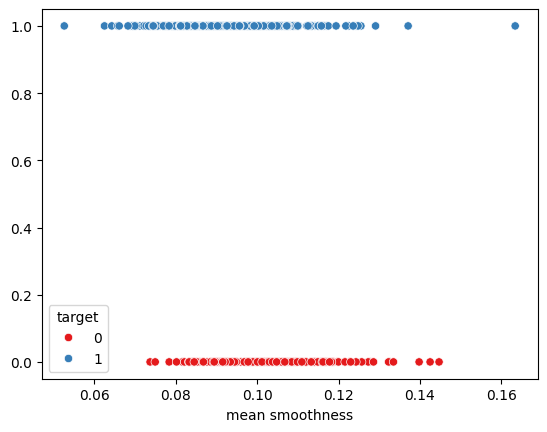

In [56]:
from sklearn.linear_model import LinearRegression
# to_show1 = "mean smoothness"
to_show1 = "mean smoothness"
# to_show2 = "perimeter error"
to_show2 = data.target

df_to_plot = df[to_show][10:20] 

sns.scatterplot(
    data=df,
    x=to_show1,
    y=to_show2,
    hue="target",
    palette="Set1"
)
vector = df[to_show1].to_numpy()


model = LinearRegression()
model.fit(vector, to_show2)


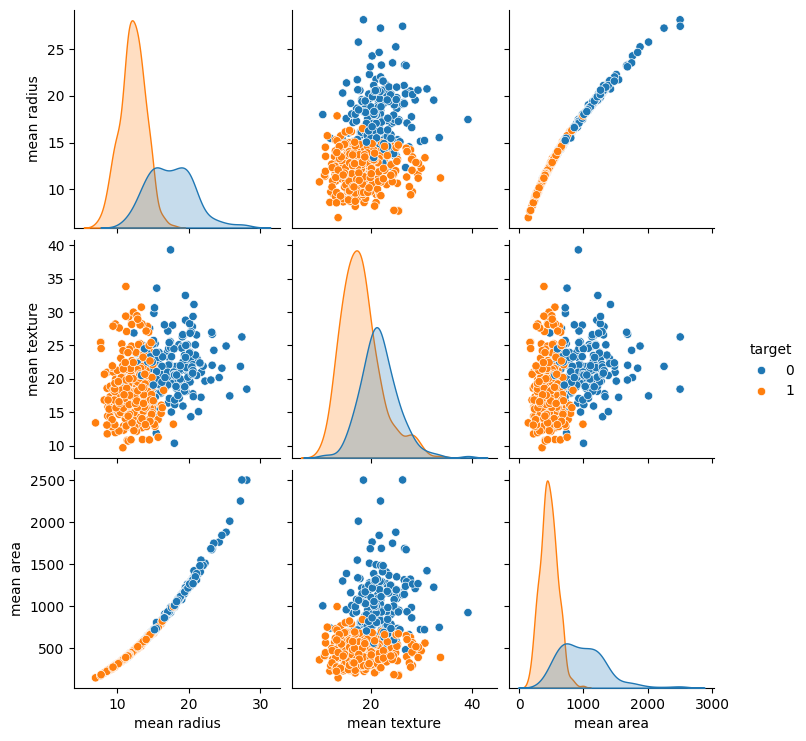

In [55]:
sns.pairplot(
    df[["mean radius", "mean texture", "mean area", "target"]],
    hue="target",
    diag_kind="kde"
)
plt.show()
